In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
np.random.seed(1)


In [5]:
def load_dataset():
    train_dataset=h5py.File("Dataset/train_happy.h5",'r')
    train_X = np.array(train_dataset["train_set_x"][:])
    train_y = np.array(train_dataset["train_set_y"][:])

    test_dataset = h5py.File("Dataset/test_happy.h5","r")
    test_X=np.array(test_dataset["test_set_x"][:])
    test_y = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_y = train_y.reshape((1,train_y.shape[0]))
    test_y=test_y.reshape((1,test_y.shape[0]))

    return train_X, train_y, test_X, test_y, classes
    

In [6]:
train_X,train_y,test_X,test_y,classes = load_dataset()
#Normalization
train_X_norm,test_X_norm = train_X/255.0,test_X/255.0
train_y,test_y=train_y.T,test_y.T

train_X_norm =np.transpose(train_X_norm, (0,3,1,2))
test_X_norm = np.transpose(test_X_norm,(0,3,1,2))


X_train, X_val, y_train, y_val = train_test_split(
    train_X_norm, 
    train_y, 
    test_size=0.20,      # 20% of the data goes to validation
    random_state=42,     # Ensures you get the exact same split every time you run the code
    stratify=train_y     # VERY IMPORTANT: Ensures the ratio of "Happy" to "Not Happy" stays the same in both sets
)

In [7]:
# Convert Numpy arrays to pytorch tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32)

X_val_tensor = torch.tensor(X_val, dtype = torch.float32)
y_val_tensor = torch.tensor(y_val, dtype = torch.float32)

X_test_tensor = torch.tensor(test_X_norm, dtype = torch.float32)
y_test_tensor = torch.tensor(test_y,dtype = torch.float32)

# Creating PyTorch dataloader
batch_size =32
train_loader = DataLoader(TensorDataset(X_train_tensor,y_train_tensor),batch_size = batch_size, shuffle = True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size = batch_size, shuffle =False)
test_loader = DataLoader(TensorDataset(X_test_tensor,y_test_tensor), batch_size = batch_size, shuffle = False)


In [9]:

# # Model layer Architecture :
# ZeroPadding2D: padding 3, input shape 64 x 64 x 3
# Conv2D: Use 32 7x7 filters, stride 1
# BatchNormalization: for axis 3
# ReLU
# DRopout - can be skipped as it is a small model with not very large dataset.
# MaxPool2D: Using default parameters
# Flatten the previous output.
# Fully-connected (Dense) layer: 
# Fully connected (Dense) layer:

class HappynessClassifier(nn.Module):
    def __init__(self):
        super(HappynessClassifier,self).__init__()
        self.features = nn.Sequential(
            # Input (3,64,64) -> output (32,64,64)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size = 7, stride =1, padding = 3),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),

            # Input (32,64,64) -> Output (32,32,32)
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            # 32 Channels * 32 height * 32 width
            nn.Linear(in_features=32*32*32, out_features=1),
            nn.Sigmoid(),
        )
    def forward(self,x):
        return self.features(x)
        

In [11]:
model = HappynessClassifier()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience =3)


In [17]:
epochs =100
patience =5
best_val_loss =float('inf')
epochs_no_improve =0
history ={'loss':[],
          'accuracy':[],
          'val_loss':[],
          'val_accuracy':[]}

for epoch in range(epochs):
    model.train()
    train_loss,train_correct,train_total=0.0,0,0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss=criterion(outputs,batch_y)
        loss.backward()
        optimizer.step()

        train_loss+= loss.item()*batch_X.size(0)

        predicted = (outputs>0.5).float()
        train_total+= batch_y.size(0)
        train_correct += (predicted==batch_y).sum().item()

    epoch_train_loss =train_loss/train_total
    epoch_train_accuracy = train_correct/train_total

    #Validation 

    model.eval()
    val_loss,val_total,val_correct = 0.0,0,0
    with torch.no_grad():
        for batch_X,batch_y, in val_loader:
            outputs = model(batch_X)
            loss=criterion(outputs,batch_y)
            val_loss+= loss.item()*batch_X.size(0)
            predicted = (outputs>0.5).float()
            val_total+=batch_y.size(0)
            val_correct+=(predicted==batch_y).sum().item()

    epoch_val_loss = val_loss/val_total
    epoch_val_accuracy = val_correct/val_total

    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_accuracy)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Loss {epoch_train_loss:.4f} - accuracy: {epoch_train_accuracy:.4f} - "
          f"val_loss: {epoch_val_loss:4f} - val_accuracy: {epoch_val_accuracy:.4f}")
    
    scheduler.step(epoch_val_loss)
    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        epochs_no_improve =0
        torch.save(model.state_dict(),'best_happyness_model.pth')
    else:
        epochs_no_improve+=1
        if epochs_no_improve>patience:
            print(f"Early Stopping triggered at epoch {epoch+1}!")
            break
            
        
          
        
    

Epoch 1/100 - Loss 0.3019 - accuracy: 0.9146 - val_loss: 0.309985 - val_accuracy: 0.9083
Epoch 2/100 - Loss 0.2418 - accuracy: 0.9271 - val_loss: 0.248041 - val_accuracy: 0.9083
Epoch 3/100 - Loss 0.2254 - accuracy: 0.9208 - val_loss: 0.186635 - val_accuracy: 0.9417
Epoch 4/100 - Loss 0.1973 - accuracy: 0.9458 - val_loss: 0.150514 - val_accuracy: 0.9750
Epoch 5/100 - Loss 0.1626 - accuracy: 0.9604 - val_loss: 0.144253 - val_accuracy: 0.9833
Epoch 6/100 - Loss 0.1515 - accuracy: 0.9667 - val_loss: 0.133703 - val_accuracy: 0.9667
Epoch 7/100 - Loss 0.1287 - accuracy: 0.9688 - val_loss: 0.116796 - val_accuracy: 0.9667
Epoch 8/100 - Loss 0.1224 - accuracy: 0.9750 - val_loss: 0.127873 - val_accuracy: 0.9500
Epoch 9/100 - Loss 0.1022 - accuracy: 0.9854 - val_loss: 0.104091 - val_accuracy: 0.9667
Epoch 10/100 - Loss 0.0965 - accuracy: 0.9833 - val_loss: 0.106531 - val_accuracy: 0.9583
Epoch 11/100 - Loss 0.0906 - accuracy: 0.9812 - val_loss: 0.120730 - val_accuracy: 0.9583
Epoch 12/100 - Loss

In [18]:
model.load_state_dict(torch.load('best_happyness_model.pth'))
model.eval()
test_correct,test_total=0,0

with torch.no_grad():
    for batch_X,batch_y in test_loader:
        outputs = model(batch_X)
        predicted = (outputs>0.5).float()
        test_total+=batch_y.size(0)
        test_correct+=(predicted==batch_y).sum().item()

print(f"Final Test Accuracy : {(test_correct/test_total)*100:.2f}%")


Final Test Accuracy : 95.33%


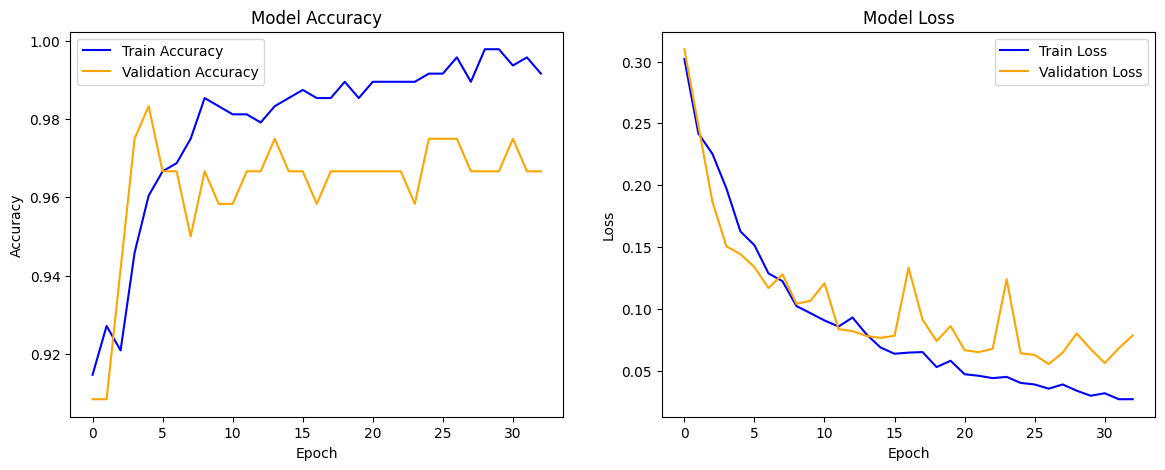

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Plot Loss
ax2.plot(history['loss'], label='Train Loss', color='blue')
ax2.plot(history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()